# Bài 1: Trực quan hóa hiện tượng quá khớp (Overfitting) của MLE so với MAP

## 1. Mô tả bài toán
- Mô phỏng bài toán tung đồng xu có xác suất xuất hiện mặt ngửa thực tế $\theta_{true} = 0.7$.
- Giả sử sau $N$ lần tung độc lập, ta quan sát được $k$ lần xuất hiện mặt ngửa ($k = \sum_{i=1}^N x_i$ với $x_i \in \{0, 1\}$).

## 2. Cơ sở lý thuyết & Công thức toán học
### Ước lượng hợp lý cực đại (MLE - Maximum Likelihood Estimation):
$$\hat{\theta}_{MLE} = \arg\max_{\theta} P(D \mid \theta) = \frac{k}{N}$$

### Ước lượng cực đại hậu nghiệm (MAP - Maximum A Posteriori):
- Phân phối tiên nghiệm: $\theta \sim \text{Beta}(\alpha=2, \beta=2)$, với hàm mật độ xác suất $P(\theta) \propto \theta^{\alpha-1}(1-\theta)^{\beta-1}$.
- Phân phối hậu nghiệm: $P(\theta \mid D) \propto P(D \mid \theta) P(\theta) \sim \text{Beta}(k + \alpha, N - k + \beta)$.
- Mode (điểm cực đại) của phân phối hậu nghiệm:
$$\hat{\theta}_{MAP} = \frac{k + \alpha - 1}{N + \alpha + \beta - 2} = \frac{k + 2 - 1}{N + 2 + 2 - 2} = \frac{k + 1}{N + 2}$$

In [1]:
# 0. Import các thư viện cần thiết
import numpy as np
import matplotlib.pyplot as plt

# Cố định random seed để kết quả mô phỏng có thể tái lập
np.random.seed(42)

In [2]:
# ==============================================================================
# YÊU CẦU 1: Tạo hàm mô phỏng tung đồng xu N lần
# ==============================================================================
def simulate_coin_toss(n, theta_true=0.7):
    """
    Mô phỏng n lần tung đồng xu độc lập.
    - Giá trị 1: Mặt ngửa (Heads) với xác suất theta_true
    - Giá trị 0: Mặt sấp (Tails) với xác suất 1 - theta_true
    """
    return np.random.binomial(n=1, p=theta_true, size=n)

# Thử nghiệm hàm mô phỏng với 10 lần tung mẫu
sample_toss = simulate_coin_toss(10, theta_true=0.7)
print("Ví dụ kết quả tung đồng xu 10 lần (1: Ngửa, 0: Sấp):")
print(sample_toss)

Ví dụ kết quả tung đồng xu 10 lần (1: Ngửa, 0: Sấp):
[1 0 0 1 1 1 1 0 1 0]


In [3]:
# ==============================================================================
# YÊU CẦU 2: Tính toán theta_MLE và theta_MAP khi N tăng dần từ 1 đến 100
# ==============================================================================
theta_true = 0.7
max_N = 100
alpha = 2
beta = 2

# Mô phỏng một chuỗi 100 lần tung đồng xu liên tiếp
toss_results = simulate_coin_toss(max_N, theta_true)

# Tính tổng tích lũy số mặt ngửa (k) sau mỗi lần tung thứ N
k_cumulative = np.cumsum(toss_results)
N_values = np.arange(1, max_N + 1)

# 1. Ước lượng MLE: k / N
theta_mle = k_cumulative / N_values

# 2. Ước lượng MAP: (k + alpha - 1) / (N + alpha + beta - 2) = (k + 1) / (N + 2)
theta_map = (k_cumulative + alpha - 1) / (N_values + alpha + beta - 2)

print(f"Tổng số lần tung: {max_N}")
print(f"Số mặt ngửa quan sát được sau {max_N} lần: {k_cumulative[-1]}")
print(f"Ước lượng MLE tại N = {max_N}: {theta_mle[-1]:.4f}")
print(f"Ước lượng MAP tại N = {max_N}: {theta_map[-1]:.4f}")

Tổng số lần tung: 100
Số mặt ngửa quan sát được sau 100 lần: 72
Ước lượng MLE tại N = 100: 0.7200
Ước lượng MAP tại N = 100: 0.7157


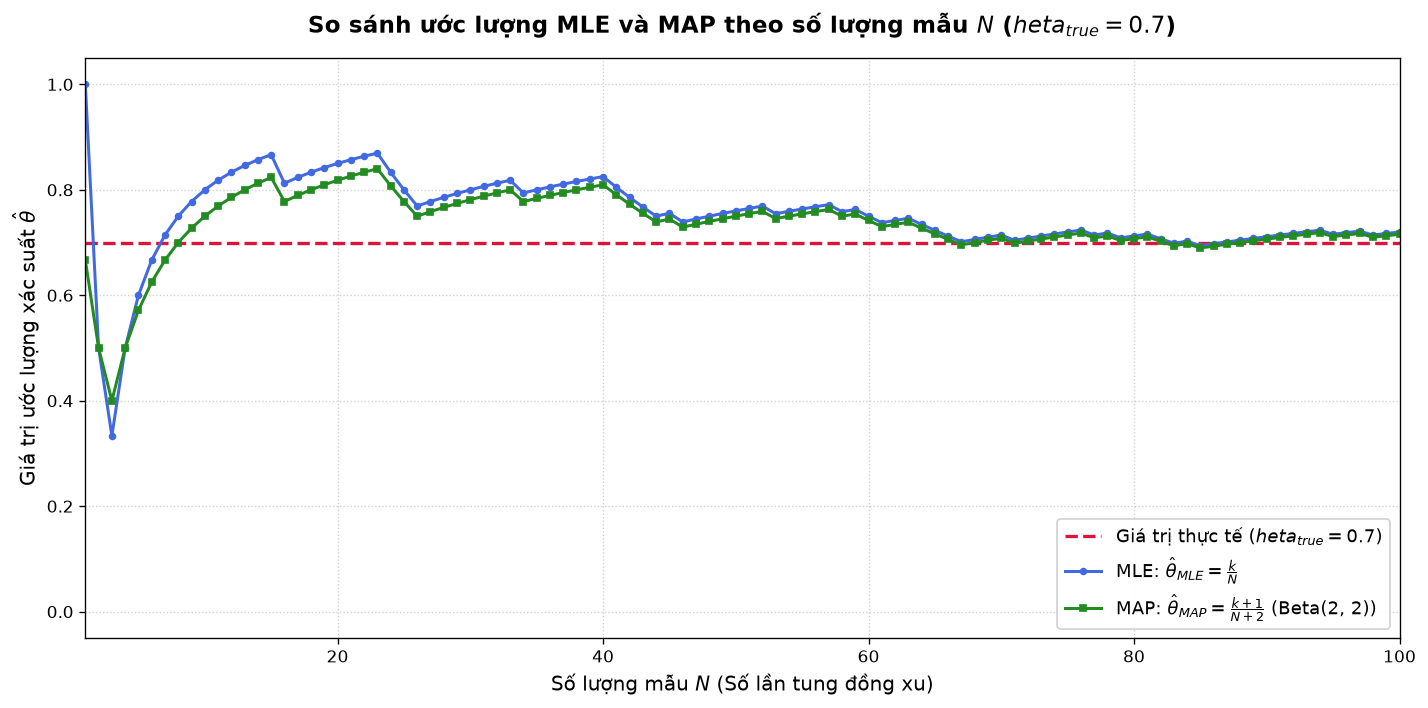

In [4]:
# ==============================================================================
# YÊU CẦU 3: Sử dụng matplotlib để vẽ đồ thị so sánh ước lượng MLE và MAP theo N
# ==============================================================================
plt.figure(figsize=(12, 6), dpi=120)

# 1. Đường giá trị xác suất thực tế theta_true
plt.axhline(y=theta_true, color='crimson', linestyle='--', linewidth=2, 
            label=f'Giá trị thực tế ($\theta_{{true}} = {theta_true}$)')

# 2. Đường ước lượng MLE
plt.plot(N_values, theta_mle, color='royalblue', marker='o', markersize=3.5, 
         linestyle='-', linewidth=1.8, label=r'MLE: $\hat{\theta}_{MLE} = \frac{k}{N}$')

# 3. Đường ước lượng MAP
plt.plot(N_values, theta_map, color='forestgreen', marker='s', markersize=3.5, 
         linestyle='-', linewidth=1.8, label=r'MAP: $\hat{\theta}_{MAP} = \frac{k+1}{N+2}$ (Beta(2, 2))')

# Cấu hình giao diện đồ thị
plt.title(r'So sánh ước lượng MLE và MAP theo số lượng mẫu $N$ ($	heta_{true} = 0.7$)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Số lượng mẫu $N$ (Số lần tung đồng xu)', fontsize=12)
plt.ylabel(r'Giá trị ước lượng xác suất $\hat{\theta}$', fontsize=12)
plt.xlim(1, max_N)
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='lower right', framealpha=0.9)
plt.tight_layout()

# Hiển thị đồ thị
plt.show()

## 3. Nhận xét chi tiết theo yêu cầu đề bài

### 1. Khi số lượng mẫu $N$ nhỏ ($N < 15$):
- **Độ dao động và hiện tượng quá khớp (Overfitting) của MLE:**
  - Giá trị ước lượng $\hat{\theta}_{MLE}$ dao động cực kỳ mạnh với biên độ lớn. Ở những lần tung đầu tiên ($N = 1, 2$), MLE rất dễ rơi vào các giá trị cực đoan ($0.0$ hoặc $1.0$) nếu ngẫu nhiên xuất hiện toàn sấp hoặc toàn ngửa.
  - **Nguyên nhân:** MLE chỉ tối ưu hóa hàm khả năng (likelihood) thuần túy dựa trên dữ liệu thu thập được mà không mang bất kỳ kiến thức nào trước đó. Khi dữ liệu quá ít, một sự ngẫu nhiên nhỏ cũng làm sai lệch hoàn toàn kết quả, dẫn đến hiện tượng **quá khớp (overfitting)** vào mẫu nhỏ.
- **Độ ổn định của MAP:**
  - Giá trị $\hat{\theta}_{MAP}$ mượt mà và ổn định hơn rất nhiều, biên độ dao động nhỏ và không bao giờ bị rơi vào các giá trị cực đoan ($0$ hay $1$).
  - **Nguyên nhân:** Phân phối tiên nghiệm $\text{Beta}(\alpha=2, \beta=2)$ đóng vai trò như một **thành phần điều chuẩn (Regularization)** (tương tự như Laplace Smoothing). Tiên nghiệm đưa vào giả định ban đầu rằng đồng xu có xu hướng cân bằng ($0.5$), giúp "kéo" ước lượng về vùng an toàn và ngăn chặn mô hình đưa ra phán đoán cực đoan khi dữ liệu chưa đủ tin cậy.

### 2. Về tốc độ hội tụ khi $N$ tăng dần ($N \to 100$):
- Theo **Định luật số lớn (Law of Large Numbers)**, khi số phép thử $N$ đủ lớn, tần suất quan sát $k/N$ sẽ hội tụ về xác suất thực $\theta_{true} = 0.7$.
- Khi $N$ tăng, ảnh hưởng của các tham số tiên nghiệm $(\alpha=2, \beta=2)$ trong công thức $\hat{\theta}_{MAP} = \frac{k + 1}{N + 2}$ trở nên không đáng kể so với kích thước mẫu $N$ và số quan sát $k$.
- Khi $N \to \infty$, ta có: $\lim_{N \to \infty} \hat{\theta}_{MAP} = \lim_{N \to \infty} \hat{\theta}_{MLE} = \theta_{true} = 0.7$.
- **Kết luận:** Cả hai phương pháp đều hội tụ về giá trị thực tế khi có đủ dữ liệu, nhưng **MAP vượt trội hơn hẳn MLE ở giai đoạn dữ liệu ít ($N$ nhỏ)** nhờ khả năng chống quá khớp và kiểm soát độ bất định tốt hơn.